# Task 6


In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from PIL import Image

## Setup

### Parameters


In [2]:
n1 = n2 = 300  # image size
n = n1 * n2  # number of pixels
beta_blur = 1000.0  # kernel blurring parameter, B = beta * I
eps = 1e-4  # threshold, entries |a_ij| < eps are set to zero
sigma = 1e-2  # noise level

### The image

Resize to $300 \times 300$ pixels, make it grayscale and scale the values to $[0, 1]$ (0 = black, 1 = white).
$X$ is the image as a matrix. We stack its columns into one vector $x$ with one entry per pixel.

X_true: (300, 300), x_true: (90000,)


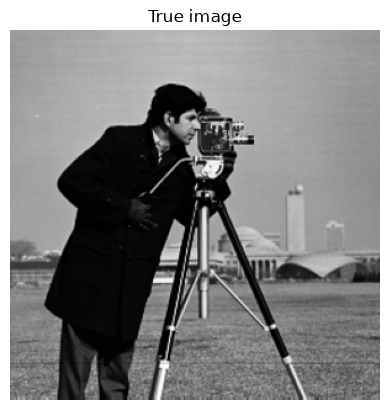

In [3]:
img = Image.open("img.png").convert("L").resize((n2, n1))
X_true = np.asarray(img, dtype=float) / 255
x_true = X_true.flatten(order="F")

print(f"X_true: {X_true.shape}, x_true: {x_true.shape}")
plt.imshow(X_true, cmap="gray")
plt.title("True image")
plt.axis("off")
plt.show()

### The blur matrix $A$

Blurring makes every pixel a weighted average of the pixels around it:
$a_{ij}$ = how much pixel $j$ in the true image contributes to pixel $i$ in the blurred image.

The weights come from the Gaussian kernel (1.9) with $B = \beta I$,
$$K(s,t) = c\,e^{-\beta \|s-t\|^2} = c\,e^{-\beta (s_1-t_1)^2}\,e^{-\beta (s_2-t_2)^2},$$
where $t$ is the position of a pixel in the true image and $s$ the position of a pixel in the blurred image.
Close pixels get a large weight, pixels far apart almost zero. Larger $\beta$ = less blur.

We place the image on $[-1,1]^2$, so each pixel has side $h = 2/300$ and its position is its midpoint.

The kernel splits into a vertical and a horizontal part, so we blur the columns with $A_1$ and the rows with $A_2$, both built like $A$ in Task 5. Then
$$A = A_2 \otimes A_1$$
(a standard Kronecker product rule, we just use it).

In [4]:
# Pixel positions along one side of the image (the midpoint grid from Task 5):
# the side [-1, 1] is split into n pixels of width h, t[j] = midpoint of pixel j
def pixel_positions(n):
    h = 2 / n  # width of one pixel
    t = -1 + (np.arange(n) + 0.5) * h  # midpoint of each pixel
    return h, t


# 1D blur matrix, same formula as A in Task 5:
# entry (i, j) = how much pixel j contributes to pixel i along one column (or row)
def blur1d(n, beta):
    h, t = pixel_positions(n)
    c = np.sqrt(beta / np.pi)  # makes each row sum to about 1
    return h * c * np.exp(-beta * (t[:, None] - t[None, :]) ** 2)


# New for Task 6: one 1D blur per direction of the image
A1 = blur1d(n1, beta_blur)  # vertical blur, acts on every column of X (n1 pixels)
A2 = blur1d(n2, beta_blur)  # horizontal blur, acts on every row of X (n2 pixels)
print(f"A1: {A1.shape}, A2: {A2.shape}")

A1: (300, 300), A2: (300, 300)


### Thresholding

Pixels far apart get tiny weights, so we set all $|a_{ij}| < \varepsilon$ to zero. Each pixel then only depends on its neighbours and $A$ becomes sparse.

The full $A$ is $90000 \times 90000$ ($\approx 65$ GB), so we remove the small entries already in $A_1$ and $A_2$ and then take the Kronecker product.

In [5]:
def build_blur_matrix(n1, n2, beta, eps):
    A1, A2 = blur1d(n1, beta), blur1d(n2, beta)
    A1s = sp.csr_matrix(np.where(A1 * A2.max() >= eps, A1, 0))
    A2s = sp.csr_matrix(np.where(A2 * A1.max() >= eps, A2, 0))
    A = sp.kron(A2s, A1s, format="csr")
    A.data[np.abs(A.data) < eps] = 0
    A.eliminate_zeros()
    return A


A = build_blur_matrix(n1, n2, beta_blur, eps)
print(f"A: {A.shape}, nnz(A) = {A.nnz:.3g}")

A: (90000, 90000), nnz(A) = 3.05e+07


### Blurred, noisy data

$$b = A x + e, \qquad e = \sigma \cdot \mathcal{N}(0, 1).$$


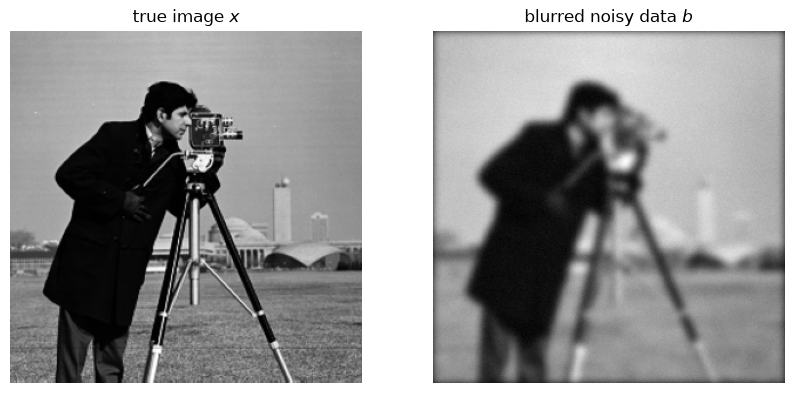

In [6]:
rng = np.random.default_rng(0)  # fixed random seed
b = A @ x_true + sigma * rng.standard_normal(n)
B_img = b.reshape((n1, n2), order="F")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(X_true, cmap="gray")
ax1.set_title("true image $x$")
ax2.imshow(B_img, cmap="gray")
ax2.set_title("blurred noisy data $b$")
for ax in (ax1, ax2):
    ax.axis("off")
plt.show()

### The regularization matrix $L_G$

$L_1, L_2$ are first-order differences, as $L$ in Task 5:
$$L_G = \begin{bmatrix} I_{n_2} \otimes L_1 \\ L_2 \otimes I_{n_1} \end{bmatrix}.$$


In [7]:
def first_difference(n):
    return sp.eye(n - 1, n) - sp.eye(n - 1, n, k=1)


L1 = first_difference(n1)
L2 = first_difference(n2)
L = sp.vstack([sp.kron(sp.eye(n2), L1), sp.kron(L2, sp.eye(n1))], format="csr")
print(f"L: {L.shape}, nnz(L) = {L.nnz}")

L: (179400, 90000), nnz(L) = 358800


## 6.1

### Sparsity pattern of $A$

Left: all of $A$. Right: the top-left $3 n_1 \times 3 n_1$ corner, which shows the block structure of $A_2 \otimes A_1$: each block is a band ($A_1$), and the blocks themselves form a band ($A_2$).


Nonzero entries of A: 0.376 %


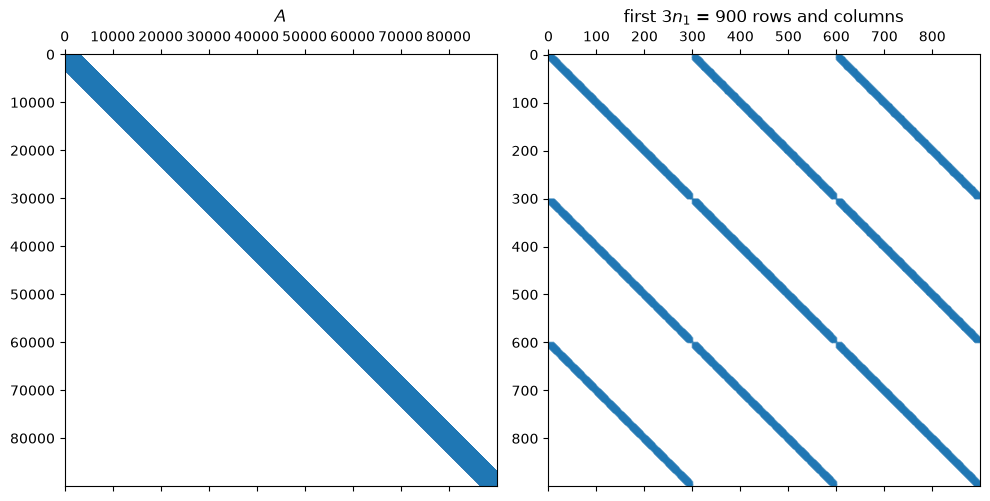

In [8]:
def percent_nonzero(A):
    return 100 * A.nnz / (A.shape[0] * A.shape[1])


print(f"Nonzero entries of A: {percent_nonzero(A):.3f} %")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.spy(A, markersize=0.01, rasterized=True)
ax1.set_title("$A$")
ax2.spy(A[: 3 * n1, : 3 * n1], markersize=0.1, rasterized=True)
ax2.set_title(f"first $3 n_1$ = {3 * n1} rows and columns")
fig.tight_layout()
fig.savefig("assets/task6_1_spy.svg")
plt.show()

### Different $\beta$ and $\varepsilon$

Larger $\beta$ means a narrower blur, and larger $\varepsilon$ removes more entries. Both make the band of $A$ thinner, so $A$ gets sparser.


  beta |    eps |   nnz(A) | nonzero %


   500 |  0.001 | 2.43e+07 |     0.300


   500 | 0.0001 | 5.13e+07 |     0.633


   500 |  1e-05 | 7.99e+07 |     0.987


  1000 |  0.001 | 1.63e+07 |     0.201


  1000 | 0.0001 | 3.05e+07 |     0.376


  1000 |  1e-05 | 4.42e+07 |     0.545


  2000 |  0.001 | 1.07e+07 |     0.132


  2000 | 0.0001 |  1.7e+07 |     0.210


  2000 |  1e-05 |  2.5e+07 |     0.308


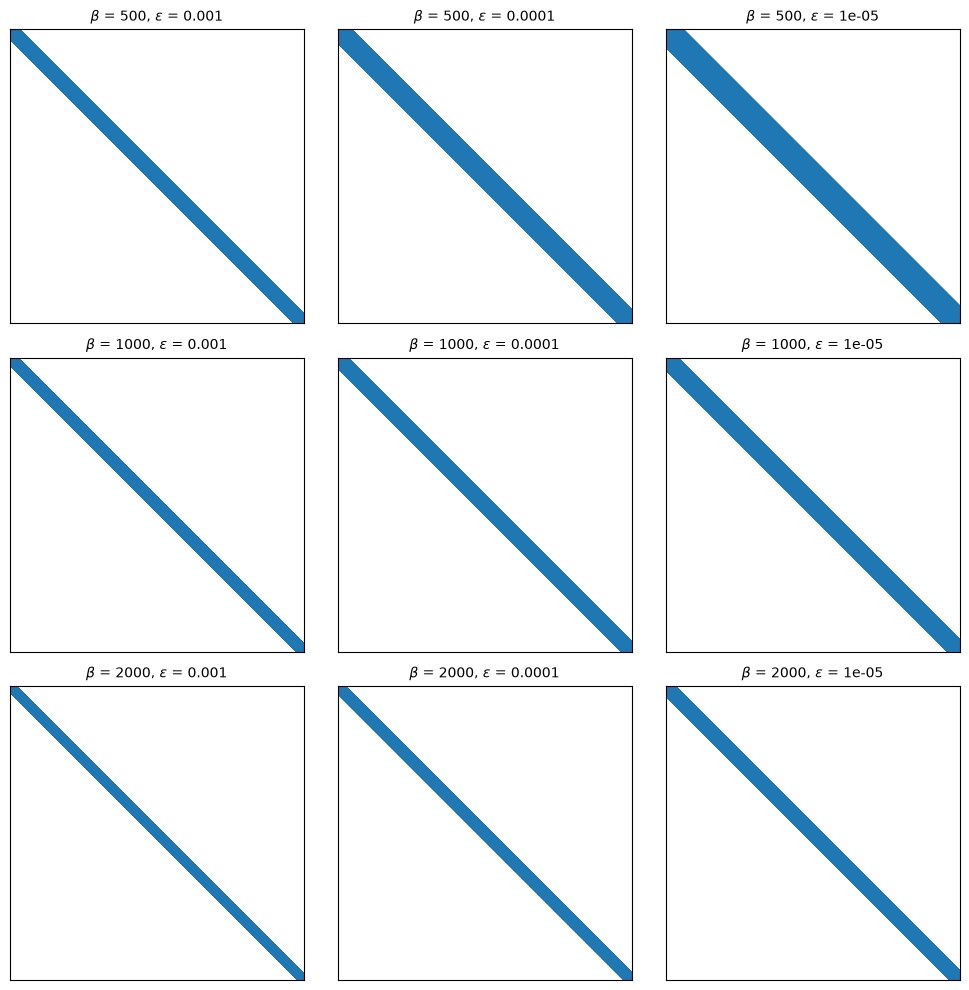

In [9]:
betas = [500, 1000, 2000]
epss = [1e-3, 1e-4, 1e-5]

fig, axes = plt.subplots(len(betas), len(epss), figsize=(10, 10))
print(f"{'beta':>6} | {'eps':>6} | {'nnz(A)':>8} | {'nonzero %':>9}")

for beta_i, row in zip(betas, axes):
    for eps_i, ax in zip(epss, row):
        A_i = build_blur_matrix(n1, n2, beta_i, eps_i)
        print(
            f"{beta_i:>6g} | {eps_i:>6g} | {A_i.nnz:>8.3g} | {percent_nonzero(A_i):>9.3f}"
        )

        ax.spy(A_i, markersize=0.01, rasterized=True)
        ax.set_title(f"$\\beta$ = {beta_i:g}, $\\varepsilon$ = {eps_i:g}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        del A_i  # free memory before the next one

fig.tight_layout()
fig.savefig("assets/task6_1_params.svg")
plt.show()

## 6.2

### Sparsity pattern of $L$

Every row of $L$ is a difference between two neighbouring pixels, so it has exactly 2 nonzeros.
- Top half, $I_{n_2} \otimes L_1$: neighbours in the same column of the image (vertical differences).
- Bottom half, $L_2 \otimes I_{n_1}$: neighbours in the same row of the image (horizontal differences), which are $n_1$ steps apart in $x$.

L: (179400, 90000), nnz(L) = 358800
Nonzero entries of L: 0.0022 %


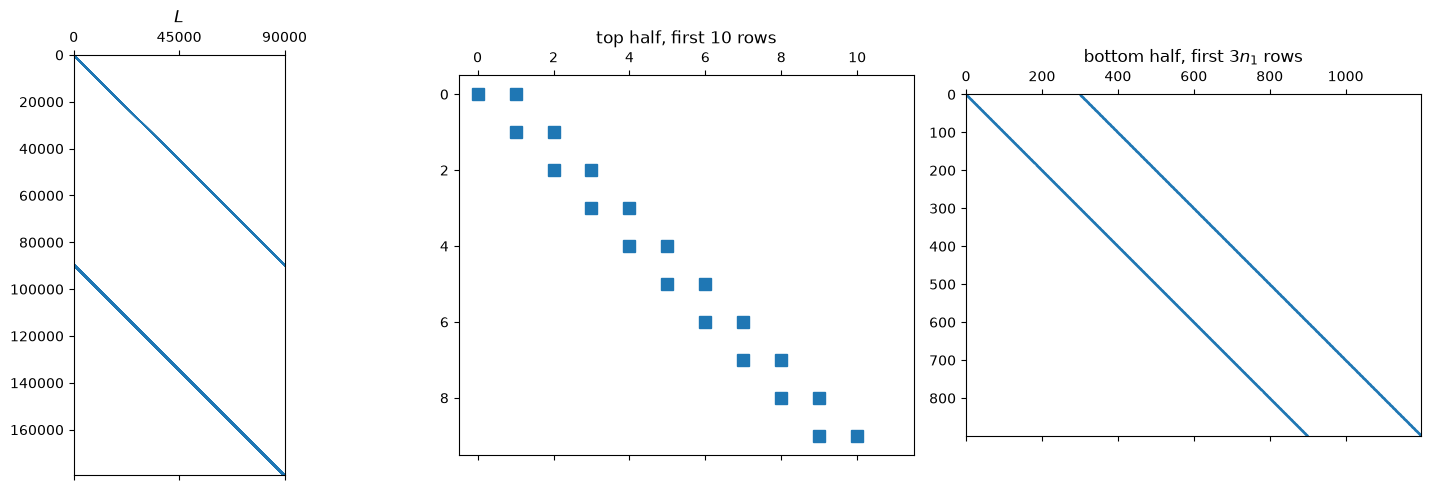

In [10]:
m_top = n2 * (n1 - 1)  # number of rows in the top half

print(f"L: {L.shape}, nnz(L) = {L.nnz}")
print(f"Nonzero entries of L: {percent_nonzero(L):.4f} %")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.spy(L, markersize=0.01, rasterized=True)
ax1.set_title("$L$")
ax1.set_xticks([0, n // 2, n])
ax2.spy(L[:10, :12], markersize=8)
ax2.set_title("top half, first 10 rows")
ax3.spy(L[m_top : m_top + 3 * n1, : 4 * n1], markersize=0.5, rasterized=True)
ax3.set_title("bottom half, first $3 n_1$ rows")
fig.tight_layout()
fig.savefig("assets/task6_2_spy.svg")
plt.show()

## 6.3

### Memory

- **Dense:** every entry is stored as an 8 byte float: $m \cdot n \cdot 8$ bytes.
- **Sparse (CSR):** only the nonzeros are stored, each as a value (8 bytes) and a column index (4 bytes), plus one row pointer (4 bytes) per row: $12\,\mathrm{nnz} + 4(m+1)$ bytes.

We compare the estimate with what scipy actually uses.

In [11]:
def dense_memory(M):
    m, n = M.shape
    return 8 * m * n


def sparse_memory(M):
    m, n = M.shape
    return 12 * M.nnz + 4 * (m + 1)


def actual_memory(M):
    return M.data.nbytes + M.indices.nbytes + M.indptr.nbytes


GB = 1e9
print(f"{'':>2} | {'dense':>11} | {'sparse':>11} | {'scipy':>11}")
for name, M in [("A", A), ("L", L)]:
    print(
        f"{name:>2} | {dense_memory(M) / GB:>8.3g} GB | {sparse_memory(M) / GB:>8.3g} GB | {actual_memory(M) / GB:>8.3g} GB"
    )

   |       dense |      sparse |       scipy
 A |     64.8 GB |    0.366 GB |    0.366 GB
 L |      129 GB |  0.00502 GB |  0.00502 GB


Dense, $A$ and $L$ need about 65 GB and 130 GB, more than a normal computer has.
Sparse, they fit easily, and $L$ is tiny since it only has 2 nonzeros per row.
The sparse size of $A$ grows with nnz, so it depends on $\beta$ and $\varepsilon$ (see 6.1).